In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df_sessions = pd.read_csv("data/sessions.csv")
df_events = pd.read_csv("data/events.csv")

print(f"loaded {len(df_events)} events!")
display(df_events.head())

loaded 44 events!


,event_id,session_id,event_timestamp,event_type,viewed_category,android_error
0,019ede42-2f7f-7051-8f66-6b6f3c10a183,019ede422f7975118cd54346b07c39cc,2023-01-30 08:13:43,view_item,Electronics,NaN
1,019ede42-2f7f-7051-8f66-6b7a80728236,019ede422f7975118cd54346b07c39cc,2023-01-30 08:13:52,add_to_cart,Electronics,NaN
2,019ede42-2f7f-7051-8f66-6b8f87f9e281,019ede422f7975118cd54346b07c39cc,2023-01-30 08:13:53,drop_off,Electronics,ERR_SESSION_TIMEOUT
3,019ede42-2f80-7df2-afce-5f5004a47307,019ede422f7975118cd543fac25809b3,2023-02-15 01:07:29,view_item,Home Goods,NaN
4,019ede42-2f80-7df2-afce-5f74b1df75c1,019ede422f7975118cd543fac25809b3,2023-02-15 01:08:23,view_item,Electronics,NaN


In [2]:
funnel_counts = df_events['event_type'].value_counts()

print("Raw Event Counts:")
display(funnel_counts)

Raw Event Counts:


event_type
view_item         25
add_to_cart        8
drop_off           8
begin_checkout     3
Name: count, dtype: int64

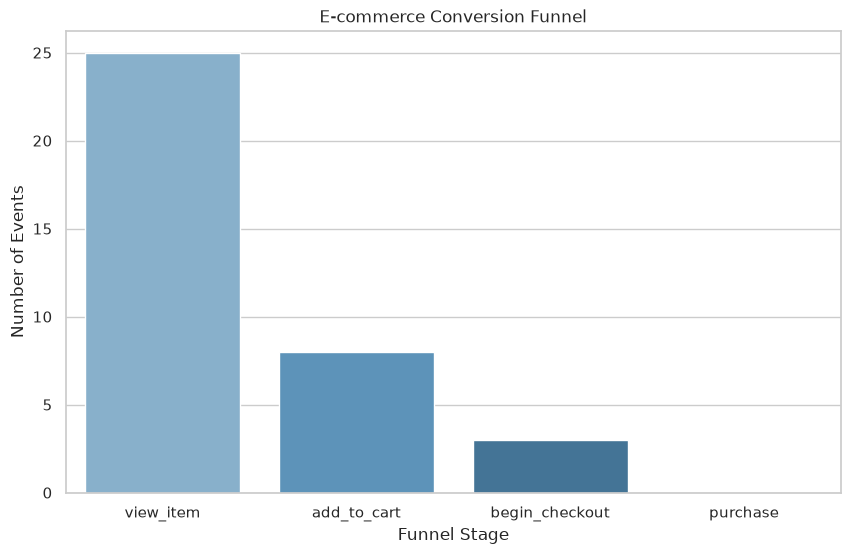

In [3]:
funnel_order = ["view_item", "add_to_cart", "begin_checkout", "purchase"]

ordered_funnel = funnel_counts.reindex(funnel_order)

plt.figure(figsize=(10, 6))
sns.barplot(x=ordered_funnel.index, y=ordered_funnel.values, hue=ordered_funnel.index, palette="Blues_d", legend=False)
plt.title("E-commerce Conversion Funnel")
plt.ylabel("Number of Events")
plt.xlabel("Funnel Stage")
plt.show()

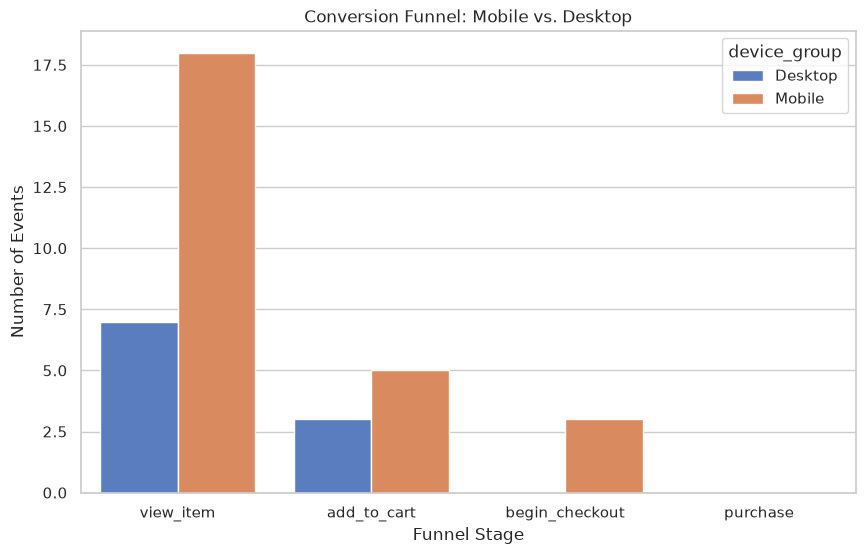

In [4]:
df_merged = df_events.merge(df_sessions[['session_id', 'device_group']], on='session_id', how='left')

device_funnel = df_merged.groupby(['device_group', 'event_type']).size().reset_index(name='count')

plt.figure(figsize=(10, 6))
sns.barplot(
    data=device_funnel, 
    x='event_type', 
    y='count', 
    hue='device_group', 
    order=funnel_order, 
    palette="muted"
)
plt.title("Conversion Funnel: Mobile vs. Desktop")
plt.ylabel("Number of Events")
plt.xlabel("Funnel Stage")
plt.show()